# 01 — Data cleaning

**รับเข้า:** `data/dataset.csv` (แถวข้อมูลจากทุกเครื่อง)
**ได้ออก:** `data/clean.csv` (พร้อมใช้ทำ EDA และเทรน)

ขั้นตอน:
1. ดูว่าเก็บอะไรมาบ้าง
2. ตรวจคุณภาพ (ค่าว่าง, row ซ้ำ, เวลาผิดปกติ, CPU ไม่ว่างตอนวัด)
3. row ที่มี mode ถูกหยุดกลางทาง (censored)
4. งานที่สั้นมาก: เก็บหรือทิ้ง
5. สร้าง label ด้วยกฎเสมอ 5%
6. เพิ่มคอลัมน์ group สำหรับแบ่ง train/test
7. แปลง log (แสดงให้ดูที่นี่ ใช้จริงตอนเทรน)
8. บันทึก `clean.csv`

หลักของ notebook นี้: **ตัดเฉพาะ row ที่พิสูจน์ได้ว่าผิด** ที่เหลือเป็นค่าที่วัดได้จริง เก็บไว้ทั้งหมด

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from helpers import (FEATURE_NAMES as F, MODES, TIME_COLS, LOG_FEATURES, COLORS, OS_COLORS,
                     INK, INK2, SURFACE, DATASET, CLEAN, tie_label, log_transform,
                     setup_plots, save, stacked_share)

setup_plots()
pd.set_option("display.width", 140)
df = pd.read_csv(DATASET)
print(f"{len(df):,} rows, {df.shape[1]} columns, {df.machine_id.nunique()} machines, "
      f"{df.template_id.nunique()} templates, {df.family.nunique()} families")

13,604 rows, 50 columns, 16 machines, 52 templates, 13 families


## 1. เก็บอะไรมาบ้าง

เครื่องมี 2 แบบ:
- **VM บน cloud** (L = Linux, W = Windows, A = AMD, R = ARM ตัวเลขคือจำนวน vCPU)
- **โน้ตบุ๊ก** (M0 = Windows, M0L = WSL Linux ส่วน `c1/c3/c6` คือจำกัดให้ใช้ 1/3/6 core)

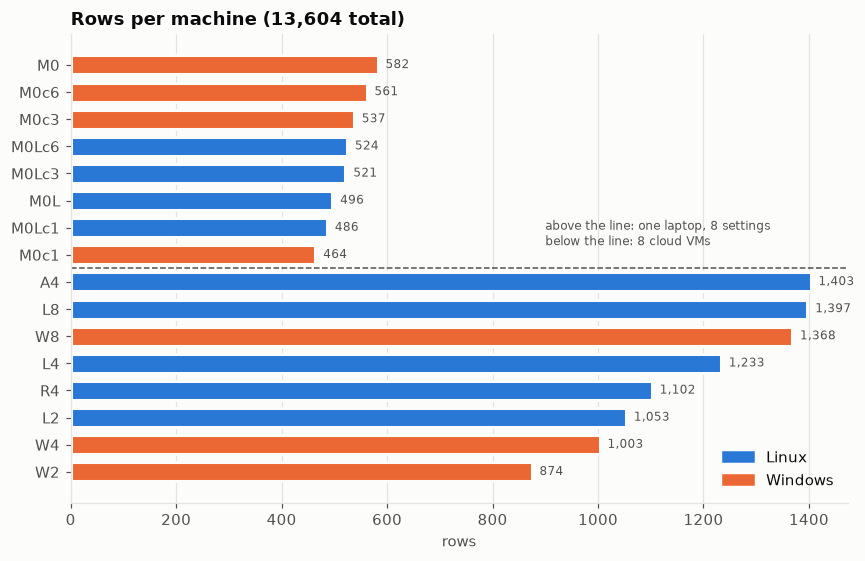

{'Linux': 0.604, 'Windows': 0.396}


In [2]:
counts = df.groupby(["machine_id", "os"]).size().reset_index(name="rows")
counts["kind"] = np.where(counts.machine_id.str.startswith("M0"), "laptop", "cloud VM")
counts = counts.sort_values(["kind", "rows"])

fig, ax = plt.subplots(figsize=(8, 5.2))
ax.barh(counts.machine_id, counts.rows, color=[OS_COLORS[o] for o in counts.os],
        height=0.7, edgecolor=SURFACE, linewidth=2)
for i, (r, k) in enumerate(zip(counts.rows, counts.kind)):
    ax.text(r + 15, i, f"{r:,}", va="center", fontsize=8, color=INK2)
n_cloud = counts.kind.eq("cloud VM").sum()
ax.axhline(n_cloud - 0.5, color=INK2, lw=1, ls="--")
ax.text(900, n_cloud + 0.2, "above the line: one laptop, 8 settings\nbelow the line: 8 cloud VMs",
        fontsize=8, color=INK2, va="bottom")
ax.grid(axis="y", visible=False)
ax.set_xlabel("rows")
ax.set_title(f"Rows per machine ({len(df):,} total)")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in OS_COLORS.values()]
ax.legend(handles, OS_COLORS.keys(), frameon=False, loc="lower right")
save(fig, "01_rows_per_machine")
plt.show()
print(df.os.value_counts(normalize=True).round(3).to_dict())

## 1.5 ตรวจ schema: ชนิดข้อมูลและช่วงค่า

ทั้ง 13 feature เป็นตัวเลข จึง**ไม่ต้อง encode** ส่วนคอลัมน์ที่เป็นข้อความหรือ ID (`machine_id`, `template_id`, `family`, `os`) ไม่ได้ใช้เป็น feature
ใช้แค่เป็น group ตอนแบ่ง data เพราะ ID ทำให้โมเดลจำแทนที่จะเรียนรู้

In [3]:
kind = {f: ("binary" if df[f].nunique() == 2 else "discrete" if df[f].nunique() <= 12 else "continuous") for f in F}
audit = df[F].describe().T[["min", "50%", "max"]]
audit.insert(0, "dtype", df[F].dtypes.astype(str))
audit.insert(1, "type", pd.Series(kind))
audit.insert(2, "n_unique", df[F].nunique())
audit

,dtype,type,n_unique,min,50%,max
n_items,int64,continuous,3568,8.000000e+00,206.000000,2.000000e+05
input_bytes,float64,continuous,7846,3.500000e+01,1268.333333,3.985642e+06
cpu_count,int64,discrete,6,1.000000e+00,4.000000,8.000000e+00
n_workers,int64,discrete,8,1.000000e+00,4.000000,1.600000e+01
max_loop_depth,int64,discrete,5,0.000000e+00,1.000000,5.000000e+00
arith_op_count,int64,discrete,12,0.000000e+00,2.000000,2.800000e+01
has_io_call,int64,binary,2,0.000000e+00,0.000000,1.000000e+00
has_gil_release_call,int64,binary,2,0.000000e+00,0.000000,1.000000e+00
time_per_item,float64,continuous,13603,9.484550e-08,0.000961,1.084946e+00
cpu_ratio,float64,continuous,5488,1.013198e-03,1.000000,1.000000e+00


## 2. ตรวจคุณภาพ

ทุกข้อควรเป็น 0 ถ้าไม่ใช่ ต้องดู row นั้นก่อนตัดสินใจ

In [4]:
checks = {
    "missing feature values":      int(df[F].isna().sum().sum()),
    "missing timings":             int(df[TIME_COLS].isna().sum().sum()),
    "duplicate run_id":            int(df.run_id.duplicated().sum()),
    "duplicate rows (features + timings)": int(df.duplicated(F + TIME_COLS).sum()),
    "timing <= 0":                 int((df[TIME_COLS] <= 0).sum().sum()),
    "non-finite feature":          int((~np.isfinite(df[F].astype(float))).sum().sum()),
    "negative feature":            int((df[F] < 0).sum().sum()),
    "measured while CPU load > 50%": int((pd.to_numeric(df.cpu_load, errors="coerce") > 50).sum()),
    "different Python versions":   df.python.nunique() - 1,
}
pd.Series(checks, name="count").to_frame()

,count
missing feature values,0
missing timings,0
duplicate run_id,0
duplicate rows (features + timings),0
timing <= 0,0
non-finite feature,0
negative feature,0
measured while CPU load > 50%,0
different Python versions,0


ตัวเก็บ data รอให้ CPU ว่าง (ต่ำกว่า 30%) ก่อนวัดทุก row ข้อนี้จึงควรผ่าน กราฟข้างล่างคือ load ตอนเริ่มวัด

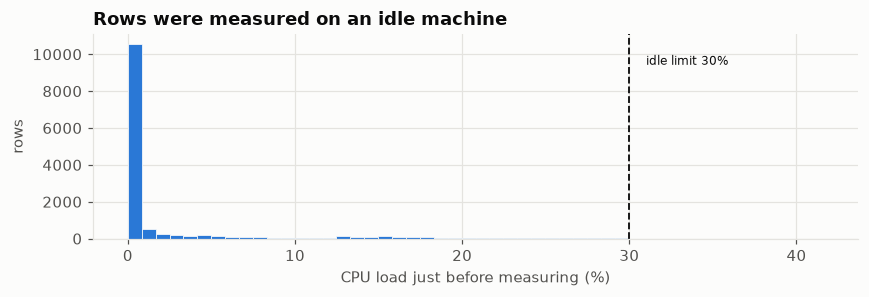

In [5]:
load = pd.to_numeric(df.cpu_load, errors="coerce")
fig, ax = plt.subplots(figsize=(8, 2.8))
ax.hist(load, bins=50, color=COLORS["sequential"], edgecolor=SURFACE, linewidth=0.5)
ax.axvline(30, color=INK, ls="--", lw=1.2)
ax.text(31, ax.get_ylim()[1] * 0.85, "idle limit 30%", fontsize=8)
ax.set_xlabel("CPU load just before measuring (%)")
ax.set_ylabel("rows")
ax.set_title("Rows were measured on an idle machine")
save(fig, "01_cpu_load")
plt.show()

## 2.5 ค่าพิเศษ (sentinel) และค่าที่ถูกตัดขอบ

ข้อมูลจริงมักใช้ค่าอย่าง -999 แทนค่าว่าง วิธีตรวจคือดูว่ามีค่าไหนซ้ำกันมากผิดปกติ

,most common value,share of rows
n_items,8.0,0.127610
cpu_ratio,1.0,0.596663


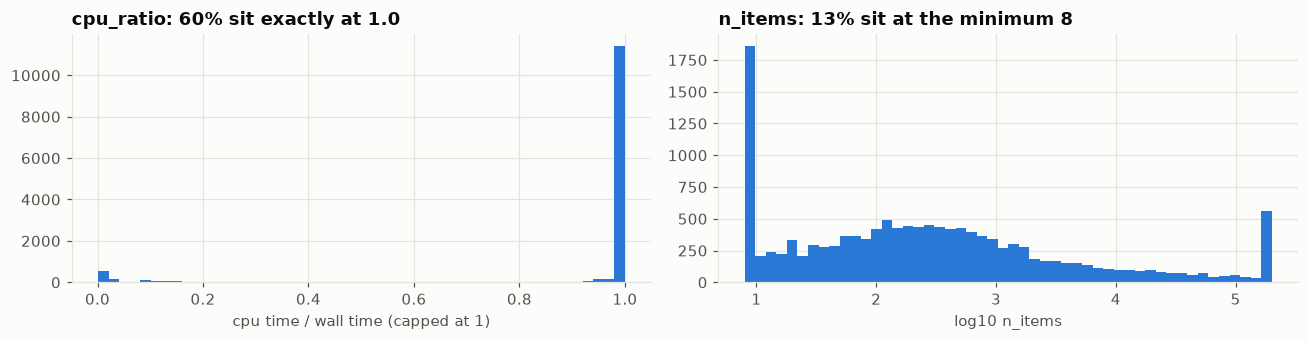

In [6]:
top = pd.DataFrame({f: {"most common value": df[f].value_counts().index[0],
                        "share of rows": df[f].value_counts(normalize=True).iloc[0]} for f in F}).T
top = top[(top["share of rows"] > 0.10) & ~top.index.isin(F[2:8])]   # skip naturally discrete ones
display(top)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.2))
axes[0].hist(df.cpu_ratio, bins=50, color=COLORS["sequential"])
axes[0].set_title("cpu_ratio: 60% sit exactly at 1.0")
axes[0].set_xlabel("cpu time / wall time (capped at 1)")
axes[1].hist(np.log10(df.n_items), bins=50, color=COLORS["sequential"])
axes[1].set_title("n_items: 13% sit at the minimum 8")
axes[1].set_xlabel("log10 n_items")
save(fig, "01_clipped_values")
plt.show()

**ไม่ใช่ sentinel ทั้งคู่ เป็นขอบที่ตั้งใจออกแบบ:**
- `cpu_ratio` = เวลา CPU / เวลาจริง ถูกจำกัดไม่เกิน 1 (`polymorph_ai/features.py`) งาน pure Python ใช้ CPU เต็มตลอดจึงได้ 1.0 พอดี มีความหมายว่า "ไม่รอ I/O เลย"
- `n_items` ขั้นต่ำคือ 8 (`MIN_ITEMS` ในสคริปต์เก็บข้อมูล) งานที่แต่ละ item ช้ามากจะถูกลดจำนวนลงเหลือ 8 เพื่อไม่ให้เกินเวลา
- **ตัดสินใจ:** เก็บไว้ตามเดิม ตอนใช้งานจริง decorator ก็คำนวณแบบเดียวกัน

## 3. row ที่มี mode ถูกหยุดกลางทาง (censored)

ถ้า mode ไหนช้ากว่าตัวที่เร็วที่สุดเกิน 5 เท่า ตัวเก็บ data จะหยุดมันก่อนเพื่อประหยัดเวลา เวลาที่บันทึกจึงเป็น**ค่าขั้นต่ำ** (ของจริงนานกว่านั้นอีก)
- mode นั้นแพ้แน่นอนอยู่แล้ว label จึงยังถูก → **เก็บ row ไว้**
- **ยกเว้น** ถ้า *label เอง* เป็น mode ที่ถูกหยุด row นั้นเชื่อไม่ได้ → **ตัดทิ้ง**

rows with a censored mode: 336 (2.5%)
rows whose LABEL is censored: 1


,run_id,template_id,t_sequential,t_threading,t_multiprocessing,censored,label
11904,W4-00672,mixed_json_roundtrip,51.570313,2.327013,3.782133,threading,threading


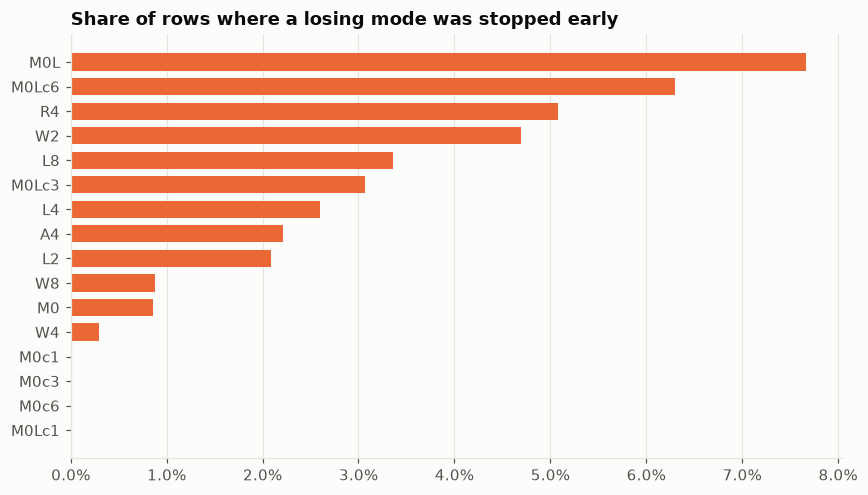

In [7]:
cens = df.censored.fillna("")
is_cens = cens != ""
label_cens = np.array([lab in c.split(";") if c else False for lab, c in zip(df.label, cens)])
print(f"rows with a censored mode: {is_cens.sum()} ({is_cens.mean():.1%})")
print(f"rows whose LABEL is censored: {label_cens.sum()}")
display(df.loc[label_cens, ["run_id", "template_id"] + TIME_COLS + ["censored", "label"]])

share = is_cens.groupby(df.machine_id).mean().sort_values()
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.barh(share.index, share.values, color=COLORS["threading"], height=0.7)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.grid(axis="y", visible=False)
ax.set_title("Share of rows where a losing mode was stopped early")
save(fig, "01_censored_per_machine")
plt.show()

In [8]:
before = len(df)
df = df.loc[~label_cens].reset_index(drop=True)
print(f"dropped {before - len(df)} row -> {len(df):,} rows")

dropped 1 row -> 13,603 rows


## 4. งานที่สั้นมาก

บางงานเสร็จในเวลาไม่ถึง 1 มิลลิวินาที เป็นค่าที่วัดผิดหรือเปล่า

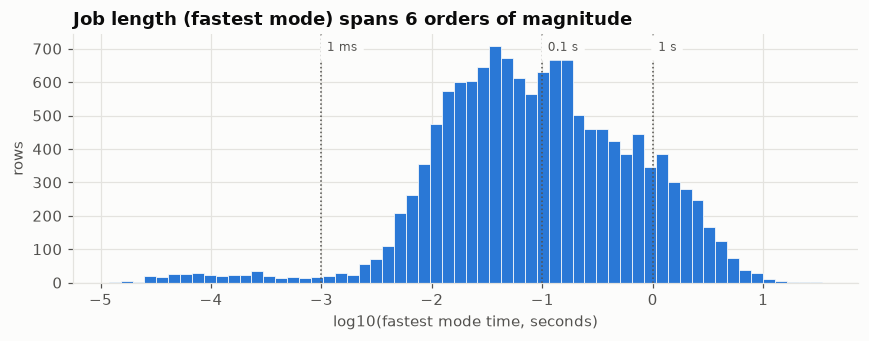

330 rows under 1 ms, by family: {'tiny': 298, 'big_payload': 25, 'recursive': 6, 'cpu': 1}
label of those rows: {'sequential': 330}


In [9]:
best = df[TIME_COLS].min(axis=1)
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.hist(np.log10(best.clip(lower=1e-6)), bins=60, color=COLORS["sequential"], edgecolor=SURFACE, linewidth=0.5)
for x, t in [(-3, "1 ms"), (-1, "0.1 s"), (0, "1 s")]:
    ax.axvline(x, color=INK2, ls=":", lw=1)
    ax.text(x + 0.05, ax.get_ylim()[1] * 0.97, t, fontsize=8, color=INK2, va='top', backgroundcolor=SURFACE)
ax.set_xlabel("log10(fastest mode time, seconds)")
ax.set_ylabel("rows")
ax.set_title("Job length (fastest mode) spans 6 orders of magnitude")
save(fig, "01_job_length")
plt.show()

short = df[best < 1e-3]
print(f"{len(short)} rows under 1 ms, by family:", short.family.value_counts().to_dict())
print("label of those rows:", short.label.value_counts().to_dict())

**ตัดสินใจ: เก็บไว้** ส่วนใหญ่เป็น family `tiny` ที่ตั้งใจสร้าง คืองานเล็กจนการเปิด pool แพงกว่าตัวงาน โมเดลต้องเรียนรู้ว่าแบบนี้ให้ตอบ *sequential*
และแทบไม่มีผลกับตัววัดหลัก เพราะเวลาที่เสียไปถ่วงตามเวลารวม

## 4.5 outlier (IQR fence)

นับ row ที่อยู่นอกช่วง Q1 − 1.5·IQR ถึง Q3 + 1.5·IQR (คิดบนสเกล log สำหรับ feature ที่ค่ากว้าง)

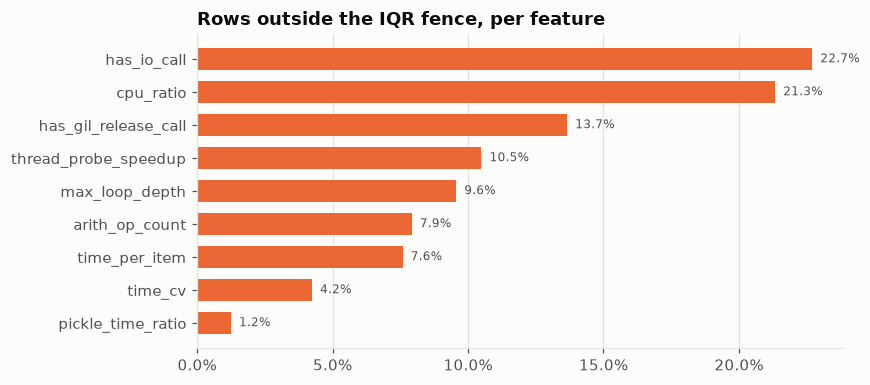

In [10]:
Xl = log_transform(df[F])
q1, q3 = Xl.quantile(0.25), Xl.quantile(0.75)
iqr = q3 - q1
out_share = ((Xl < q1 - 1.5 * iqr) | (Xl > q3 + 1.5 * iqr)).mean().sort_values()
out_share = out_share[out_share > 0]

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.barh(out_share.index, out_share.values, color=COLORS["threading"], height=0.65)
for i, v in enumerate(out_share.values):
    ax.text(v + 0.003, i, f"{v:.1%}", va="center", fontsize=8, color=INK2)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.grid(axis="y", visible=False)
ax.set_title("Rows outside the IQR fence, per feature")
save(fig, "01_outliers_iqr")
plt.show()

**ตัดสินใจ: ไม่ลบ outlier**
- ส่วนใหญ่ไม่ใช่ค่าผิด แต่เป็น**กลุ่มงานที่มีน้อยกว่า** เช่น `has_io_call` = 1 มีแค่ 23% ของ row IQR จึงนับว่าเป็น outlier ทั้งที่เป็นงาน I/O ตามปกติ
- `cpu_ratio` ต่ำ = งานที่รอ I/O ซึ่งคือกลุ่มที่ threading ชนะ ถ้าลบทิ้ง โมเดลจะไม่รู้จัก threading
- ไม่มีค่าที่เป็นไปไม่ได้ (ข้อ 2 ตรวจแล้วว่าไม่มีค่าติดลบ ไม่มี inf ไม่มีเวลา ≤ 0)
- Random Forest ไม่สนใจ outlier อยู่แล้ว ส่วน MLP ใช้ log ช่วยลดผลของค่าสุดขั้ว

## 5. label ด้วยกฎเสมอ 5%

label เดิม = mode ที่เร็วที่สุด แต่ถ้า 2 mode ห่างกันไม่ถึง 5% ความต่างนั้นเป็นแค่ noise
**กฎ:** ห่างไม่ถึง 5% → เลือก mode ที่ถูกกว่า (sequential < threading < multiprocessing)

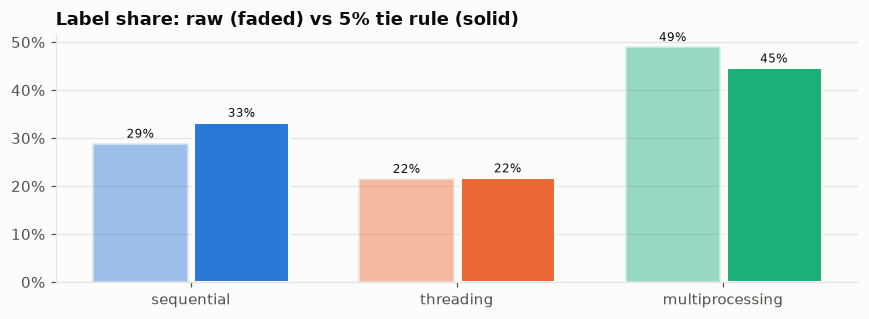

label changed by the tie rule: 7.1% of rows
tie rule         multiprocessing  sequential  threading
raw                                                    
multiprocessing             6085         233        374
sequential                     0        3955          0
threading                      0         357       2599


In [11]:
times = df[TIME_COLS].to_numpy()
df["y"] = tie_label(times)

comp = pd.DataFrame({"raw fastest": df.label.value_counts(normalize=True),
                     "5% tie rule": df.y.value_counts(normalize=True)}).loc[MODES]
fig, ax = plt.subplots(figsize=(8, 3))
x = np.arange(len(MODES))
for k, (col, alpha) in enumerate([("raw fastest", 0.45), ("5% tie rule", 1.0)]):
    bars = ax.bar(x + (k - 0.5) * 0.38, comp[col], width=0.36, color=[COLORS[m] for m in MODES],
                  alpha=alpha, edgecolor=SURFACE, linewidth=2)
    for b, v in zip(bars, comp[col]):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f"{v:.0%}", ha="center", fontsize=8)
ax.set_xticks(x, MODES)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.grid(axis="x", visible=False)
ax.set_title("Label share: raw (faded) vs 5% tie rule (solid)")
save(fig, "01_tie_rule")
plt.show()
changed = (df.y != df.label).mean()
print(f"label changed by the tie rule: {changed:.1%} of rows")
print(pd.crosstab(df.label, df.y, rownames=["raw"], colnames=["tie rule"]))

## 6. คอลัมน์ group สำหรับแบ่ง train/test

row จาก template เดียวกัน (หรือเครื่องเดียวกัน) ห้ามอยู่ทั้งใน train และ test ไม่งั้นคะแนนจะสูงเกินจริง
- `machine_group`: ทุกชุดบนโน้ตบุ๊ก (M0, M0L, M0c*, M0Lc*) เป็นเครื่องจริง**เครื่องเดียว** → นับเป็น group เดียว
- `is_laptop`, `cores_limited`: ใช้เทียบเพิ่มเติมใน EDA

In [12]:
df["machine_group"] = np.where(df.machine_id.str.startswith("M0"), "M0", df.machine_id)
df["is_laptop"] = df.machine_id.str.startswith("M0")
df["cores_limited"] = df.machine_id.str.contains(r"^M0L?c\d", regex=True)
df["best_time"] = df[TIME_COLS].min(axis=1)

print("groups for leave-one-machine-out:", df.machine_group.nunique(), sorted(df.machine_group.unique()))
print("groups for GroupKFold by template:", df.template_id.nunique())
print("groups for leave-one-family-out:", df.family.nunique())

groups for leave-one-machine-out: 9 ['A4', 'L2', 'L4', 'L8', 'M0', 'R4', 'W2', 'W4', 'W8']
groups for GroupKFold by template: 52
groups for leave-one-family-out: 13


## 7. แปลง log (สำหรับ MLP)

มี 6 feature ที่ค่าห่างกันถึงล้านเท่า neural net จะเห็น row เกือบทั้งหมดอัดกันอยู่ใกล้ 0
`log10` ช่วยกระจายค่าออก ส่วน Random Forest ไม่ต้องแปลง (สนใจแค่ลำดับค่า)

การแปลงนี้ไม่ต้อง fit อะไร จึงทำก่อนแบ่ง data ได้ปลอดภัย **แต่ standardize (mean/std) ไม่ทำที่นี่** ต้อง fit บน train fold เท่านั้นตอนเทรน

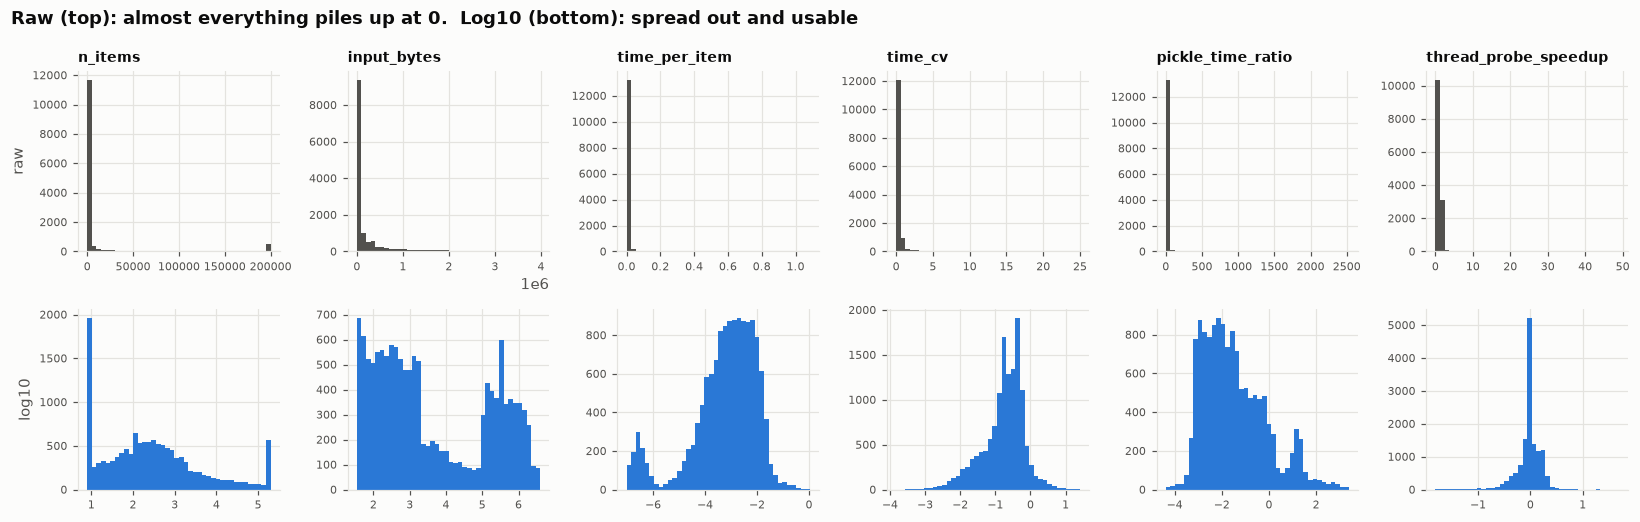

In [13]:
X_log = log_transform(df[F])
fig, axes = plt.subplots(2, len(LOG_FEATURES), figsize=(15, 4.8))
for j, f in enumerate(LOG_FEATURES):
    axes[0, j].hist(df[f], bins=40, color=INK2)
    axes[1, j].hist(X_log[f], bins=40, color=COLORS["sequential"])
    axes[0, j].set_title(f, fontsize=9)
    for a in axes[:, j]:
        a.tick_params(labelsize=7)
axes[0, 0].set_ylabel("raw")
axes[1, 0].set_ylabel("log10")
fig.suptitle("Raw (top): almost everything piles up at 0.  Log10 (bottom): spread out and usable",
             x=0.01, ha="left", fontweight="bold")
save(fig, "01_log_transform")
plt.show()

## 8. บันทึก `clean.csv`

คอลัมน์ที่เก็บ: id และ group, 13 feature, เวลาของแต่ละ mode (ต้องใช้คำนวณเวลาที่เสียไป) และ label ทั้ง 2 แบบ

In [14]:
keep = (["run_id", "machine_id", "machine_group", "os", "vm_size", "physical_cores",
         "is_laptop", "cores_limited",
         "family", "template_id", "duration_tier", "input_tier"]
        + F + TIME_COLS + ["best_time", "censored", "label", "y"])
df[keep].to_csv(CLEAN, index=False)
print(f"saved {CLEAN}: {len(df):,} rows x {len(keep)} columns")
print("label (y):", df.y.value_counts().to_dict())

saved data\clean.csv: 13,603 rows x 32 columns
label (y): {'multiprocessing': 6085, 'sequential': 4545, 'threading': 2973}


## สรุป

- data สะอาดอยู่แล้ว: ไม่มีค่าว่าง ไม่มี row ซ้ำ ไม่มีเวลาผิดปกติ ทุก row วัดตอน CPU ว่าง
- ตัดทิ้ง **1 row** (label เป็น mode ที่ถูกหยุดกลางทาง)
- ไม่มี sentinel (`cpu_ratio` = 1 และ `n_items` = 8 เป็นขอบที่ออกแบบไว้) และไม่ลบ outlier เพราะเป็นกลุ่มงานจริงที่มีน้อย
- เก็บงานที่สั้นมากไว้ (สอนโมเดลว่าเมื่อไหร่*ไม่ควร*ทำขนาน)
- label ใช้กฎเสมอ 5% และเพิ่มคอลัมน์ group สำหรับแบ่ง data อย่างยุติธรรม
- แปลง log แสดงไว้ที่นี่ ส่วน standardize และ class weight ทำใน train fold ตอนเทรน

ถัดไป: `02_exploratory_data_analysis.ipynb`